In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_or=pd.DataFrame([[0,0,0,0],[0,0,1,1],[0,1,0,1],[0,1,1,1],[1,0,0,1],[1,0,1,1],[1,1,0,1],[1,1,1,1]],columns=["Input_01","Input_02","Input_03","Result"])
df_or

,Input_01,Input_02,Input_03,Result
0,0,0,0,0
1,0,0,1,1
2,0,1,0,1
3,0,1,1,1
4,1,0,0,1
5,1,0,1,1
6,1,1,0,1
7,1,1,1,1


In [3]:
df_and=pd.DataFrame([[0,0,0,0],[0,0,1,0],[0,1,0,0],[0,1,1,0],[1,0,0,0],[1,0,1,0],[1,1,0,0],[1,1,1,1]],columns=["Input_01","Input_02","Input_03","Result"])
df_and

,Input_01,Input_02,Input_03,Result
0,0,0,0,0
1,0,0,1,0
2,0,1,0,0
3,0,1,1,0
4,1,0,0,0
5,1,0,1,0
6,1,1,0,0
7,1,1,1,1


In [4]:
df_not=pd.DataFrame([[0,1],[1,0]],columns=["Input_01","Result"])
df_not

,Input_01,Result
0,0,1
1,1,0


In [5]:
w1=w2=w3=0
lr=0.1
b=0
max_iter=20

In [6]:
def forward_pass(inp_x,w1,w2,w3,b):
  num=inp_x.iloc[0]*w1+inp_x.iloc[1]*w2+inp_x.iloc[2]*w3+b
  return step_fun(num)

In [7]:
def is_true(pred,true):
  return pred==true;

In [8]:
def step_fun(num):
  if num>=0:
    return 1
  else:
    return 0

In [9]:
def plot_decision_boundary(df_x,df_y,w1,w2,w3,b,epoch,var):

    plt.figure(figsize=(6,5))

    for i in range(df_x.shape[0]):

        if df_y.iloc[i]==0:
            plt.scatter(
                df_x.iloc[i,0],
                df_x.iloc[i,1],
                color="red",
                marker="o",
                s=100
            )

        else:
            plt.scatter(
                df_x.iloc[i,0],
                df_x.iloc[i,1],
                color="blue",
                marker="x",
                s=100
            )

    input_03=0


    if w2!=0:

        x=np.linspace(-0.5,1.5,100)

        y=-(w1*x+w3*input_03+b)/w2

        plt.plot(
            x,
            y,
            color="black",
            label="Decision Boundary"
        )


    plt.xlabel("Input_01")
    plt.ylabel("Input_02")
    plt.title("Decision Boundary after Epoch "+str(epoch))

    plt.xlim(-0.5,1.5)
    plt.ylim(-0.5,1.5)

    plt.grid()
    plt.legend()
    plt.savefig(f"plots/{var}_epoch_{epoch}.png")
    plt.show()

In [10]:
def forward_propagation(df_x,df_y,w1,w2,w3,b):
  misclassified_pts=0
  for i in range(df_x.shape[0]):
    inp=df_x.iloc[i]
    num=forward_pass(inp,w1,w2,w3,b)
    flag=is_true(num,df_y.iloc[i])
    if flag==False:
      w1,w2,w3,b=weight_update(w1,w2,w3,b,inp,df_y.iloc[i],num)
      misclassified_pts+=1
  return w1,w2,w3,b,misclassified_pts

In [11]:
def weight_update(w1,w2,w3,b,df_x,df_y,pred):
  error=df_y-pred
  w1=w1+lr*error*df_x.iloc[0]
  w2=w2+lr*error*df_x.iloc[1]
  w3=w3+lr*error*df_x.iloc[2]
  b=b+lr*error
  print("Weights Update occured, new weights are: ",w1,w2,w3,"bias: ",b)
  return w1,w2,w3,b

In [12]:
def epoch_loop(w1,w2,w3,b,df_x,df_y,var):
  for i in range(max_iter):
    w1,w2,w3,b,misclassified_pts=forward_propagation(df_x,df_y,w1,w2,w3,b)
    print("Weights at the end of epoch ",i+1,"are",w1,w2,w3,"and bias is",b,"With misclassified pts are",misclassified_pts)
    plot_decision_boundary(df_x,df_y,w1,w2,w3,b,i+1,var)
    if misclassified_pts==0:
      break
  return w1,w2,w3,b

Or gate
Weights Update occured, new weights are:  0.0 0.0 0.0 bias:  -0.1
Weights Update occured, new weights are:  0.0 0.0 0.1 bias:  0.0
Weights at the end of epoch  1 are 0.0 0.0 0.1 and bias is 0.0 With misclassified pts are 2


C:\Users\Mohula prasath\AppData\Local\Temp\ipykernel_7920\3453910913.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


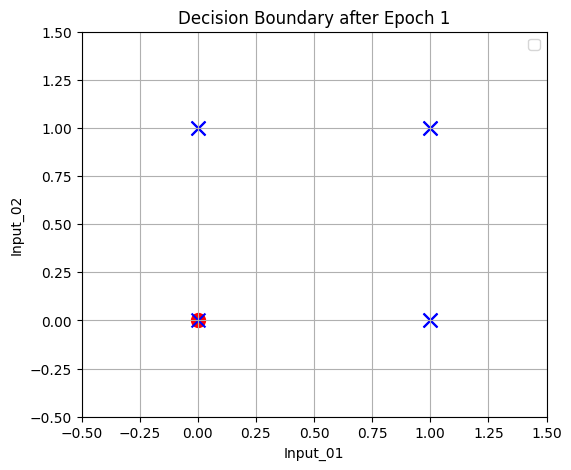

Weights Update occured, new weights are:  0.0 0.0 0.1 bias:  -0.1
Weights Update occured, new weights are:  0.0 0.1 0.1 bias:  0.0
Weights at the end of epoch  2 are 0.0 0.1 0.1 and bias is 0.0 With misclassified pts are 2


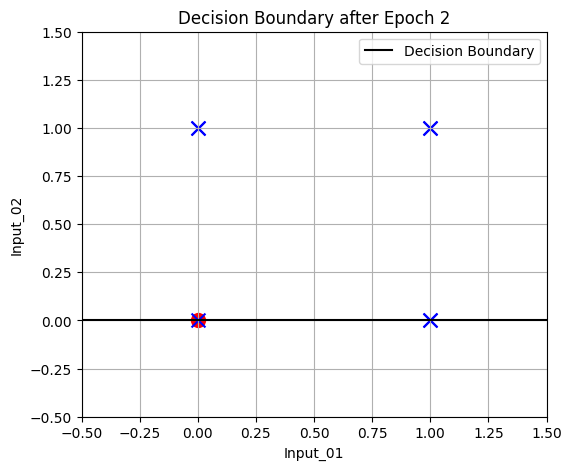

Weights Update occured, new weights are:  0.0 0.1 0.1 bias:  -0.1
Weights Update occured, new weights are:  0.1 0.1 0.1 bias:  0.0
Weights at the end of epoch  3 are 0.1 0.1 0.1 and bias is 0.0 With misclassified pts are 2


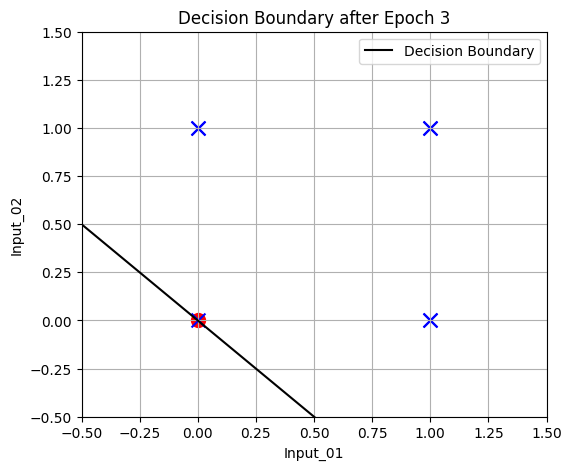

Weights Update occured, new weights are:  0.1 0.1 0.1 bias:  -0.1
Weights at the end of epoch  4 are 0.1 0.1 0.1 and bias is -0.1 With misclassified pts are 1


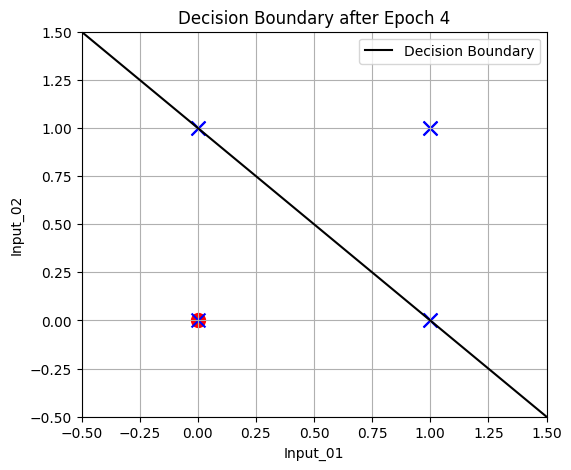

Weights at the end of epoch  5 are 0.1 0.1 0.1 and bias is -0.1 With misclassified pts are 0


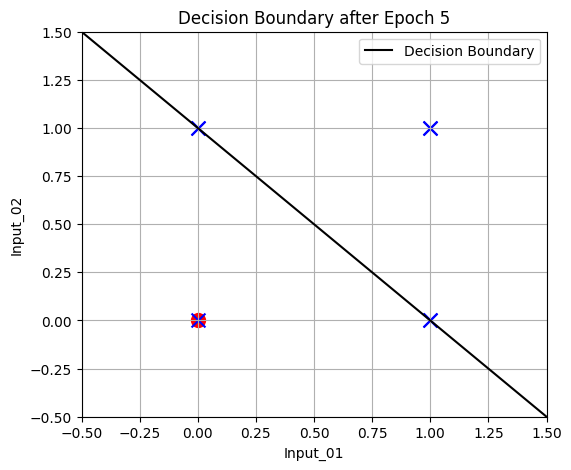

Final weights for or gate are:  0.1 0.1 0.1 and bias is -0.1


In [13]:
print("Or gate")
w1,w2,w3,b=epoch_loop(w1,w2,w3,b,df_or.iloc[:,0:3],df_or.iloc[:,3],"Or")
print("Final weights for or gate are: ",w1,w2,w3,"and bias is",b)

In [14]:
w1=w2=w3=0
lr=0.1
b=0

And gate
Weights Update occured, new weights are:  0.0 0.0 0.0 bias:  -0.1
Weights Update occured, new weights are:  0.1 0.1 0.1 bias:  0.0
Weights at the end of epoch  1 are 0.1 0.1 0.1 and bias is 0.0 With misclassified pts are 2


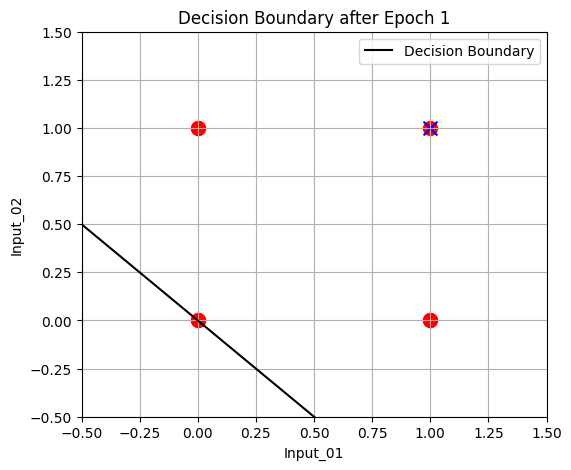

Weights Update occured, new weights are:  0.1 0.1 0.1 bias:  -0.1
Weights Update occured, new weights are:  0.1 0.1 0.0 bias:  -0.2
Weights Update occured, new weights are:  0.0 0.0 0.0 bias:  -0.30000000000000004
Weights Update occured, new weights are:  0.1 0.1 0.1 bias:  -0.20000000000000004
Weights at the end of epoch  2 are 0.1 0.1 0.1 and bias is -0.20000000000000004 With misclassified pts are 4


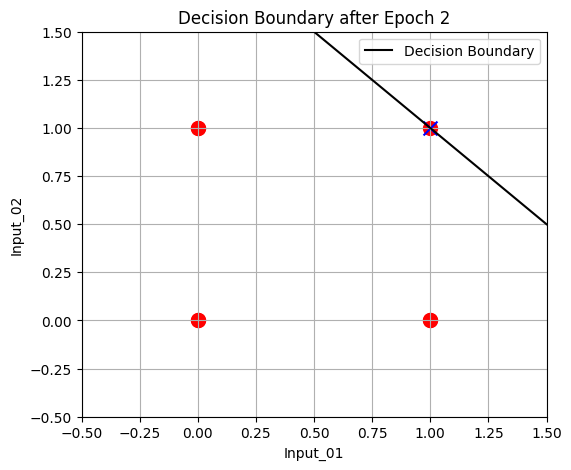

Weights at the end of epoch  3 are 0.1 0.1 0.1 and bias is -0.20000000000000004 With misclassified pts are 0


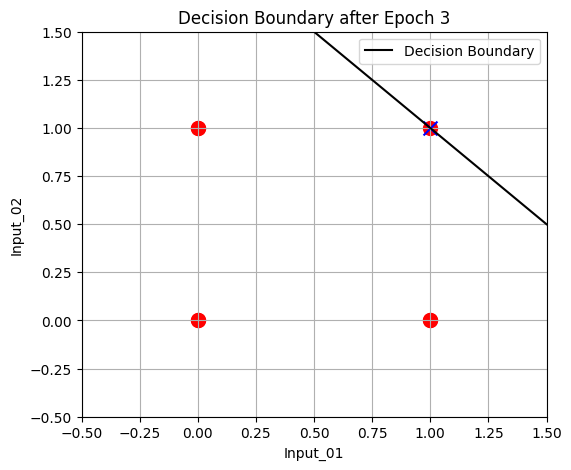

Final weights for and gate are:  0.1 0.1 0.1 and bias is -0.20000000000000004


In [15]:
print("And gate")
w1,w2,w3,b=epoch_loop(w1,w2,w3,b,df_and.iloc[:,0:3],df_and.iloc[:,3],"and")
print("Final weights for and gate are: ",w1,w2,w3,"and bias is",b)

In [16]:
w1=w2=w3=0
lr=0.1
b=0

In [17]:
def forward_pass_not(inp,w1,b):
  num=inp*w1+b
  return step_fun(num)

In [18]:
def plot_decision_boundary_not(df_x,df_y,w1,b,epoch):

    plt.figure(figsize=(6,3))


    for i in range(df_x.shape[0]):

        if df_y.iloc[i]==0:
            plt.scatter(df_x.iloc[i],0,
                        color="red",
                        s=100)

        else:
            plt.scatter(df_x.iloc[i],0,
                        color="blue",
                        s=100)


    if w1 != 0:

        x = np.linspace(-1,2,100)

        y = -(w1*x+b)

        plt.plot(
            x,
            y,
            color="black",
            label="Boundary"
        )


    plt.xlabel("Input_01")
    plt.title("NOT Gate Decision Boundary after Epoch "+str(epoch))
    plt.grid()
    plt.legend()
    plt.savefig(f"plots/not_epoch_{epoch}.png")
    plt.show()

In [19]:
def forward_propagation_not(df_x,df_y,w1,b):
  misclassified_pts=0
  for i in range(df_x.shape[0]):
    inp=df_x.iloc[i]
    num=forward_pass_not(inp,w1,b)
    flag=is_true(num,df_y.iloc[i])
    if flag==False:
      w1,b=weight_update_not(w1,b,inp,df_y.iloc[i],num)
      misclassified_pts+=1
  return w1,b,misclassified_pts

In [20]:
def weight_update_not(w1,b,inp,true,pred):
  error=true-pred
  w1=w1+lr*error*inp
  b=b+lr*error
  print("Weights Update occured, new weight is: ",w1,"bias: ",b)
  return w1,b

In [21]:
def epoch_loop_not(w1,b,df_x,df_y):
  for i in range(max_iter):
    w1,b,misclassified_pts=forward_propagation_not(df_x,df_y,w1,b)
    print("Weights at the end of epoch ",i+1,"is",w1,"and bias is",b,"With misclassified pts are",misclassified_pts)
    plot_decision_boundary_not(df_x,df_y,w1,b,i+1)
    if misclassified_pts==0:
      break
  return w1,b

Not gate
Weights Update occured, new weight is:  -0.1 bias:  -0.1
Weights at the end of epoch  1 is -0.1 and bias is -0.1 With misclassified pts are 1


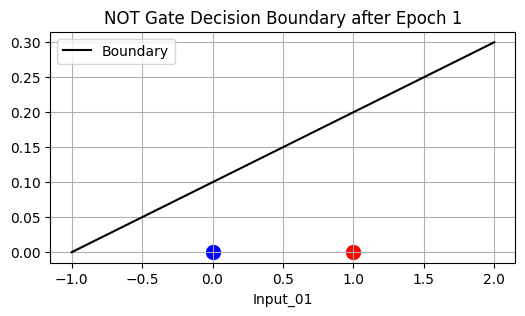

Weights Update occured, new weight is:  -0.1 bias:  0.0
Weights at the end of epoch  2 is -0.1 and bias is 0.0 With misclassified pts are 1


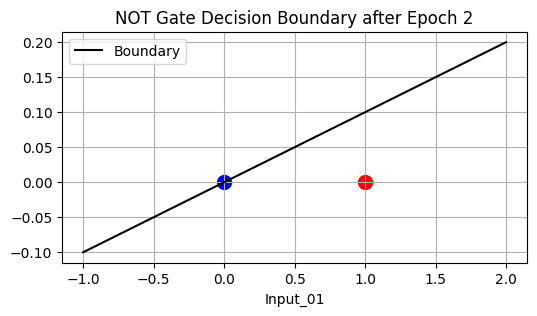

Weights at the end of epoch  3 is -0.1 and bias is 0.0 With misclassified pts are 0


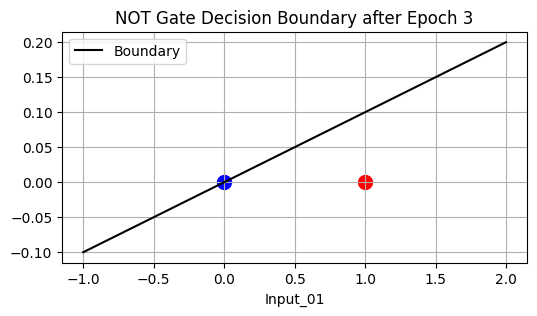

Final weights for not gate is:  -0.1 and bias is 0.0


In [22]:
print("Not gate")
w1,b=epoch_loop_not(w1,b,df_not.iloc[:,0],df_not.iloc[:,1])
print("Final weights for not gate is: ",w1,"and bias is",b)